In [1]:
import pandas as pd

In [2]:
# Define color palette
main_blue = '#2E86C1'
top_green = '#27AE60'
bottom_red = '#C0392B'
neutral_grey = '#7F8C8D'


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/etyurkay/TIL6022-Group-Project/Pranshu/Data/Processed/merged_eurostat_clean.csv"
data = pd.read_csv(url)

data.head()



,geo,TIME_PERIOD,rail_total_mio_tkm,unit,rail_length_km,rail_modal_share_pc,rail_freight_total_mio_tkm,total_tkm,TRN_FUL,WAG_FUL
0,AT,2008,21915.0,MIO_TKM,0.0,33.6,NaN,NaN,NaN,NaN
1,AT,2009,17767.0,MIO_TKM,0.0,32.0,NaN,NaN,NaN,NaN
2,AT,2010,19833.0,MIO_TKM,0.0,33.0,NaN,NaN,NaN,NaN
3,AT,2011,20345.0,MIO_TKM,0.0,33.1,NaN,NaN,NaN,NaN
4,AT,2012,19499.0,MIO_TKM,0.0,32.7,NaN,NaN,NaN,NaN


In [4]:
data.columns

Index(['geo', 'TIME_PERIOD', 'rail_total_mio_tkm', 'unit', 'rail_length_km',
       'rail_modal_share_pc', 'rail_freight_total_mio_tkm', 'total_tkm',
       'TRN_FUL', 'WAG_FUL'],
      dtype='object')

In [5]:
# Analyzing rail freight data to find top 5 and bottom 5 countries by total rail freight in million tonne-kilometers
country_totals = (
    data.groupby('geo')['rail_freight_total_mio_tkm']
    .sum()
    .sort_values(ascending=False)
)

top5 = country_totals.head(5)
bottom5 = country_totals.tail(5)

top5, bottom5


(geo
 DE    11584788.0
 PL     6862298.0
 FR     2960144.0
 AT     2925524.0
 IT     2805890.0
 Name: rail_freight_total_mio_tkm, dtype: float64,
 geo
 DK    251506.0
 LU    104852.0
 EL     20450.0
 IE     13138.0
 BE         0.0
 Name: rail_freight_total_mio_tkm, dtype: float64)

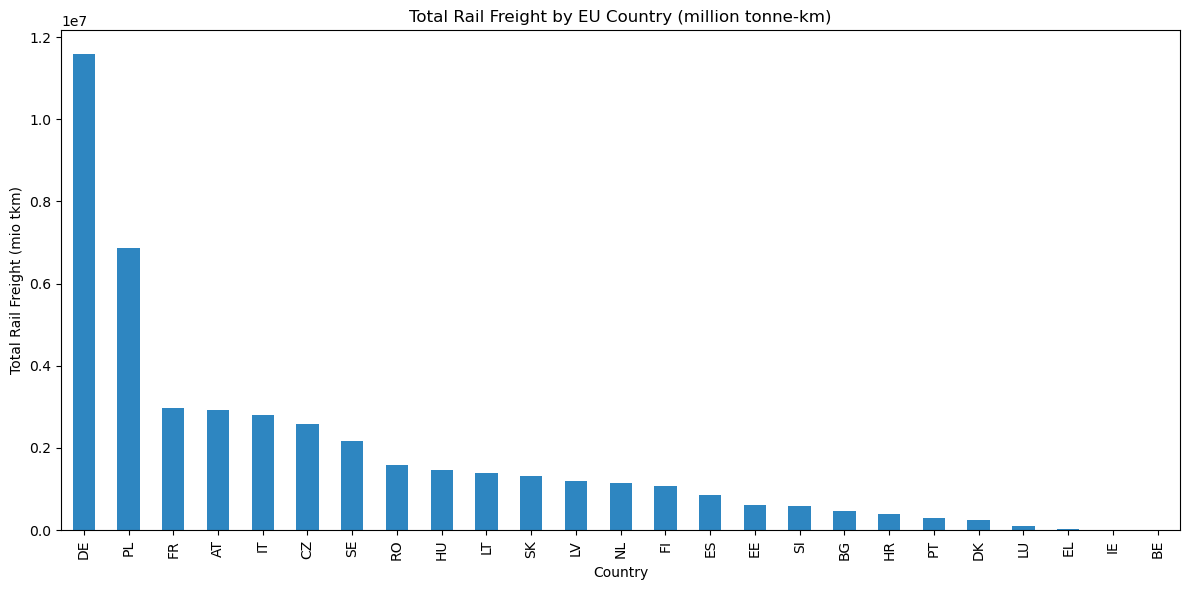

In [6]:
# Visualizing the total rail freight for each country using a bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
country_totals.plot(kind='bar', color=main_blue)
plt.title('Total Rail Freight by EU Country (million tonne-km)')
plt.xlabel('Country')
plt.ylabel('Total Rail Freight (mio tkm)')
plt.tight_layout()
plt.show()



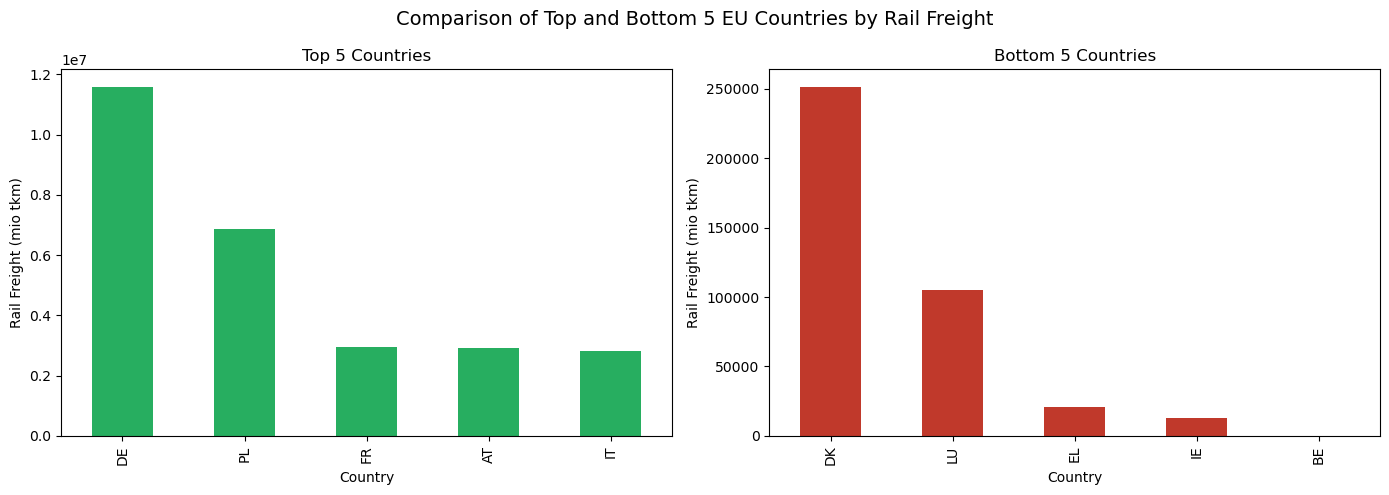

In [7]:
# Comparing top 5 and bottom 5 countries side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))

top5.plot(kind='bar', color=top_green, ax=axes[0])
axes[0].set_title('Top 5 Countries')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Rail Freight (mio tkm)')

bottom5.plot(kind='bar', color=bottom_red, ax=axes[1])
axes[1].set_title('Bottom 5 Countries')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Rail Freight (mio tkm)')

fig.suptitle('Comparison of Top and Bottom 5 EU Countries by Rail Freight', fontsize=14)
plt.tight_layout()
plt.show()


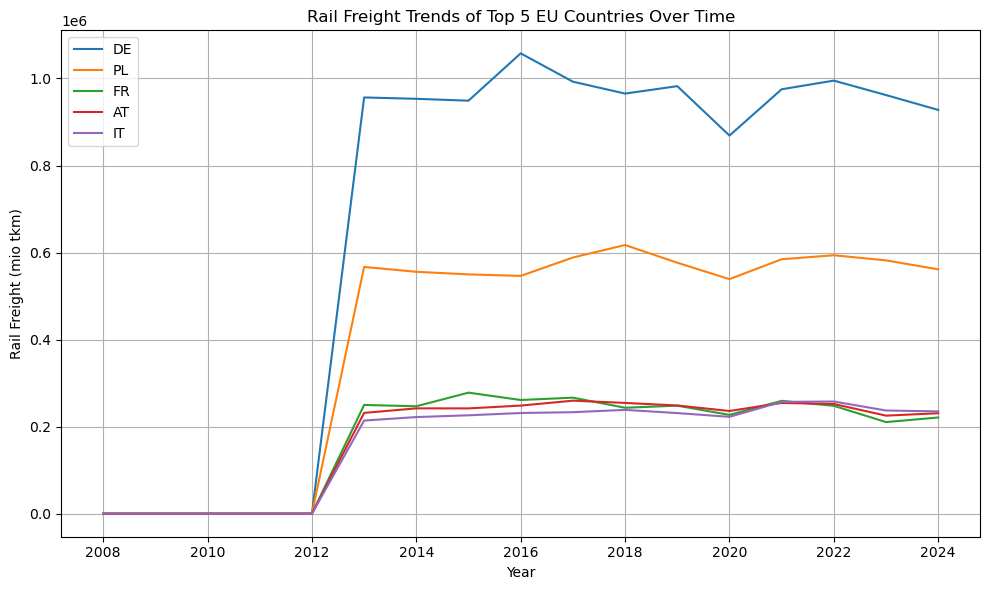

In [8]:
# Filter only top 5 countries
top_countries = data[data['geo'].isin(top5.index)]

# Group by year and country
trend = top_countries.groupby(['TIME_PERIOD', 'geo'])['rail_freight_total_mio_tkm'].sum().reset_index()

plt.figure(figsize=(10,6))
for country in top5.index:
    subset = trend[trend['geo'] == country]
    plt.plot(subset['TIME_PERIOD'], subset['rail_freight_total_mio_tkm'], label=country)

plt.title('Rail Freight Trends of Top 5 EU Countries Over Time')
plt.xlabel('Year')
plt.ylabel('Rail Freight (mio tkm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
